# Indirect Object Identification (IOI) Circuit: Replication + Template Stability Extension

This notebook replicates the core IOI circuit found by Wang et al. (2022) in GPT-2 small, and extends it by testing whether the same circuit components (Name Mover Heads, S-Inhibition Heads) remain causally load-bearing across distractor-token prompt variations — a lightweight probe into circuit stability, motivated by Neel Nanda's open problem list on interpretability robustness.

## 0. Setup

In [1]:
!pip install transformer_lens einops circuitsvis -q

import torch
import einops
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from functools import partial
import os

from transformer_lens import HookedTransformer, utils

torch.set_grad_enabled(False)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

RESULTS_DIR = "../results"
os.makedirs(RESULTS_DIR, exist_ok=True)

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 78.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 5.3 MB/s eta 0:00:00
Using device: cuda


/tmp/ipykernel_1374/4292422891.py:11: DeprecationWarning: The 'utils' module has been deprecated. Please use 'transformer_lens.utilities' instead. Importing from utils.py will be removed in TransformerLens 4.0.
  from transformer_lens import HookedTransformer, utils


In [2]:
model = HookedTransformer.from_pretrained("gpt2", device=device)
model.set_use_attn_result(True)
n_layers, n_heads = model.cfg.n_layers, model.cfg.n_heads
print(model.cfg)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Loaded pretrained model gpt2 into HookedTransformer
HookedTransformerConfig:
{'NTK_by_parts_factor': 8.0,
 'NTK_by_parts_high_freq_factor': 4.0,
 'NTK_by_parts_low_freq_factor': 1.0,
 'NTK_original_ctx_len': 8192,
 'act_fn': 'gelu_new',
 'attention_dir': 'causal',
 'attn_only': False,
 'attn_scale': np.float64(8.0),
 'attn_scores_soft_cap': -1.0,
 'attn_types': None,
 'checkpoint_index': None,
 'checkpoint_label_type': None,
 'checkpoint_value': None,
 'd_head': 64,
 'd_mlp': 3072,
 'd_model': 768,
 'd_vocab': 50257,
 'd_vocab_out': 50257,
 'decoder_start_token_id': None,
 'default_prepend_bos': True,
 'device': 'cuda',
 'dtype': torch.float32,
 'eps': 1e-05,
 'experts_per_token': None,
 'final_rms': False,
 'from_checkpoint': False,
 'gated_mlp': False,
 'init_mode': 'gpt2',
 'init_weights': False,
 'initializer_range': np.float64(0.02886751345948129),
 'layer_norm_folding': False,
 'load_in_4bit': False,
 'model_name': 'gpt2',
 'n_ctx': 1024,
 'n_devices': 1,
 'n_heads': 12,
 'n_key_

## 1. IOI Dataset Construction

Base template (ABBA form, as in Wang et al.): *"When [A] and [B] went to the store, [B] gave a drink to [A]"* — the correct completion is the Indirect Object (IO), the name that appears once (A), not the Subject (S), which repeats (B).

We build:
- **Base set**: standard IOI templates across multiple name pairs
- **Distractor set**: same templates but with an irrelevant third named entity inserted mid-sentence, to test whether the circuit is robust to surface-level noise

In [3]:
NAMES = ["John", "Mary", "Tom", "Alice", "Peter", "Sarah", "David", "Anna"]
PLACES = ["the store", "the park", "the office", "the school"]
OBJECTS = ["a drink", "a book", "a ring", "a gift"]

BASE_TEMPLATE = "When {A} and {B} went to {place}, {B} gave {obj} to"
# Distractor: an irrelevant named entity inserted in a subordinate clause
DISTRACTOR_TEMPLATE = "When {A} and {B} went to {place} with {C}, {B} gave {obj} to"

def make_ioi_prompt(template, rng, distractor=False):
    a, b = rng.choice(NAMES, size=2, replace=False)
    place = rng.choice(PLACES)
    obj = rng.choice(OBJECTS)
    if distractor:
        remaining = [n for n in NAMES if n not in (a, b)]
        c = rng.choice(remaining)
        text = template.format(A=a, B=b, place=place, obj=obj, C=c)
    else:
        text = template.format(A=a, B=b, place=place, obj=obj)
    return text, a, b  # IO = a, S = b

def build_dataset(n, template, distractor=False, seed=0):
    rng = np.random.default_rng(seed)
    prompts, io_names, s_names = [], [], []
    while len(prompts) < n:
        text, a, b = make_ioi_prompt(template, rng, distractor)
        # ensure single-token names for clean logit comparison
        if len(model.to_str_tokens(" " + a, prepend_bos=False)) == 1 and \
           len(model.to_str_tokens(" " + b, prepend_bos=False)) == 1:
            prompts.append(text)
            io_names.append(a)
            s_names.append(b)
    return prompts, io_names, s_names

N_PROMPTS = 40
base_prompts, base_io, base_s = build_dataset(N_PROMPTS, BASE_TEMPLATE, distractor=False, seed=0)
distractor_prompts, dist_io, dist_s = build_dataset(N_PROMPTS, DISTRACTOR_TEMPLATE, distractor=True, seed=1)

print("Base example: ", base_prompts[0], "| IO:", base_io[0], "| S:", base_s[0])
print("Distractor example:", distractor_prompts[0], "| IO:", dist_io[0], "| S:", dist_s[0])

Base example:  When Sarah and Anna went to the park, Anna gave a book to | IO: Sarah | S: Anna
Distractor example: When Alice and Peter went to the school with John, Peter gave a drink to | IO: Alice | S: Peter


## 2. Logit Difference Metric

For each prompt, the model should assign higher logit to the IO name token than the S name token at the final position. Logit diff = logit(IO) - logit(S).

In [5]:
def tokenize_with_answers(prompts, io_names, s_names):
    tokens = model.to_tokens(prompts)
    io_tok = torch.tensor([model.to_single_token(" " + n) for n in io_names], device=device)
    s_tok = torch.tensor([model.to_single_token(" " + n) for n in s_names], device=device)
    return tokens, io_tok, s_tok

def logit_diff(logits, io_tok, s_tok, per_prompt=False):
    final_logits = logits[:, -1, :]
    io_tok = io_tok.to(final_logits.device)
    s_tok = s_tok.to(final_logits.device)
    io_logits = final_logits.gather(1, io_tok.unsqueeze(1)).squeeze(1)
    s_logits = final_logits.gather(1, s_tok.unsqueeze(1)).squeeze(1)
    diff = io_logits - s_logits
    return diff if per_prompt else diff.mean()

base_tokens, base_io_tok, base_s_tok = tokenize_with_answers(base_prompts, base_io, base_s)
base_logits, base_cache = model.run_with_cache(base_tokens)
base_ld = logit_diff(base_logits, base_io_tok, base_s_tok)
print(f"Base template mean logit diff (IO - S): {base_ld.item():.3f}")

Base template mean logit diff (IO - S): 3.161


## 3. Direct Logit Attribution (DLA)

Project each attention head's output (via the unembedding) directly onto the logit-diff direction, to find which heads write the IO vs S signal into the residual stream at the final token.

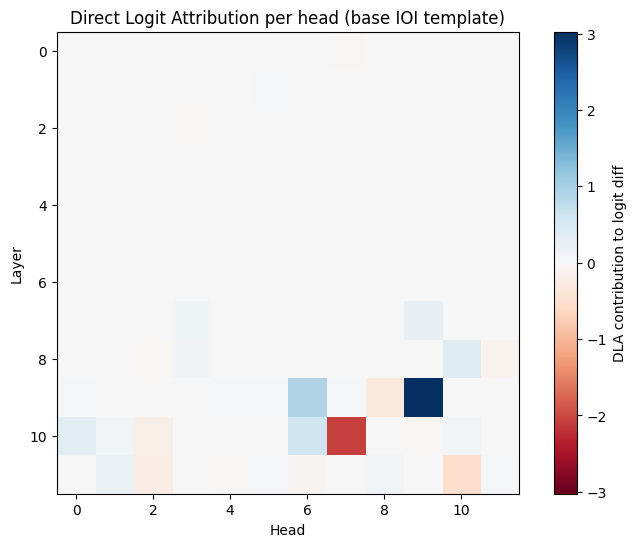

Top 10 heads by DLA (candidate Name Mover Heads):
  L9H9: 3.026
  L9H6: 0.903
  L10H6: 0.608
  L8H10: 0.394
  L10H0: 0.348
  L7H9: 0.241
  L11H1: 0.206
  L7H3: 0.124
  L8H3: 0.113
  L10H1: 0.079


In [6]:
def get_dla_per_head(cache, io_tok, s_tok):
    """Returns [n_layers, n_heads] tensor of average DLA contribution to logit diff."""
    answer_residual_directions = model.tokens_to_residual_directions(
        torch.stack([io_tok, s_tok], dim=1)
    )  # [batch, 2, d_model]
    logit_diff_direction = answer_residual_directions[:, 0] - answer_residual_directions[:, 1]  # [batch, d_model]

    per_head_result = torch.zeros(n_layers, n_heads)
    scale = cache["ln_final.hook_scale"][:, -1, :]  # [batch, 1]
    for layer in range(n_layers):
        head_out = cache["result", layer][:, -1, :, :]  # [batch, head, d_model]
        normalized = head_out / scale.unsqueeze(1)
        contrib = einops.einsum(
            normalized, logit_diff_direction,
            "batch head d_model, batch d_model -> batch head"
        )
        per_head_result[layer] = contrib.mean(0)
    return per_head_result

dla = get_dla_per_head(base_cache, base_io_tok, base_s_tok)

plt.figure(figsize=(9, 6))
plt.imshow(dla, cmap="RdBu", vmin=-dla.abs().max(), vmax=dla.abs().max())
plt.colorbar(label="DLA contribution to logit diff")
plt.xlabel("Head"); plt.ylabel("Layer")
plt.title("Direct Logit Attribution per head (base IOI template)")
plt.savefig(f"{RESULTS_DIR}/dla_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

top_heads = sorted(
    [(l, h, dla[l, h].item()) for l in range(n_layers) for h in range(n_heads)],
    key=lambda x: -x[2]
)[:10]
print("Top 10 heads by DLA (candidate Name Mover Heads):")
for l, h, v in top_heads:
    print(f"  L{l}H{h}: {v:.3f}")

## 4. Attention Pattern Visualization

Wang et al. identify Name Mover Heads at approx. L9H9, L9H6, L10H0 and S-Inhibition Heads around L7-8. We visualize attention patterns for the top DLA heads to confirm they attend to the IO token at the final position.

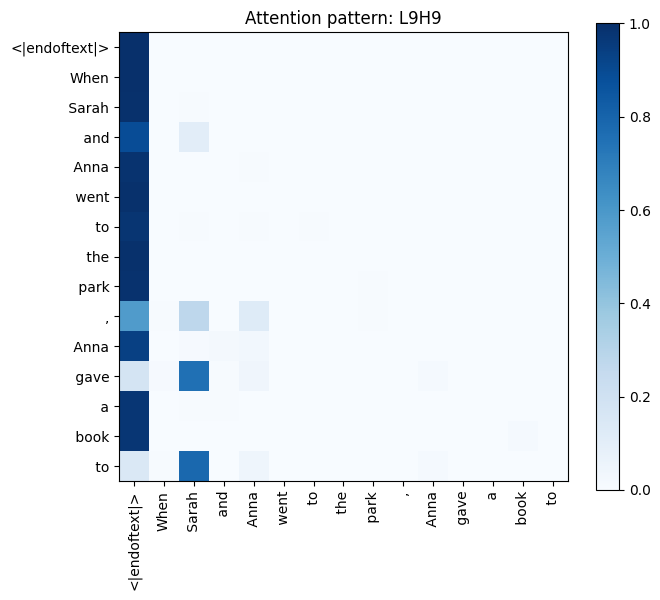

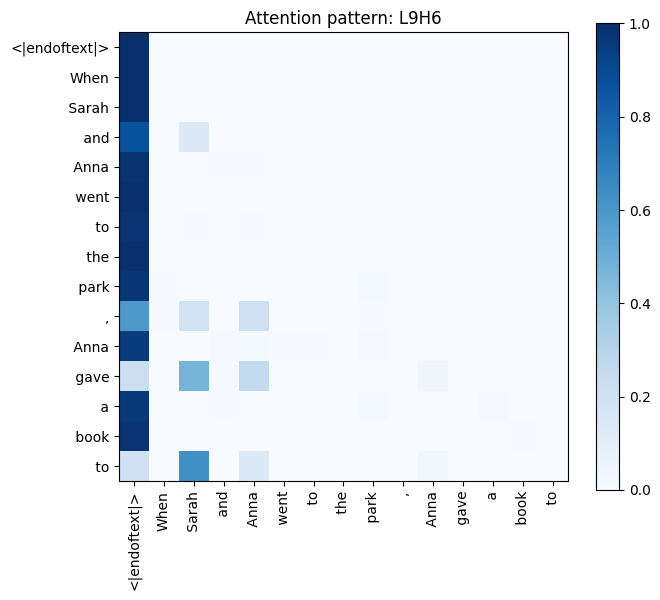

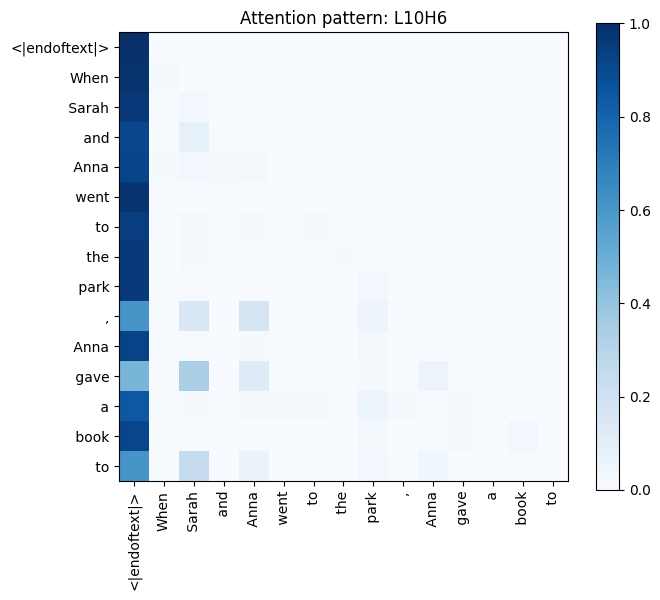

In [7]:
def plot_attention_pattern(cache, layer, head, tokens_str, save_name):
    pattern = cache["pattern", layer][0, head].cpu().numpy()  # first prompt in batch
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(pattern, cmap="Blues")
    ax.set_xticks(range(len(tokens_str))); ax.set_xticklabels(tokens_str, rotation=90)
    ax.set_yticks(range(len(tokens_str))); ax.set_yticklabels(tokens_str)
    ax.set_title(f"Attention pattern: L{layer}H{head}")
    plt.colorbar(im)
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/{save_name}.png", dpi=150)
    plt.show()

example_tokens_str = model.to_str_tokens(base_prompts[0])
for l, h, _ in top_heads[:3]:
    plot_attention_pattern(base_cache, l, h, example_tokens_str, f"attn_L{l}H{h}")

## 5. Path Patching: Causal Verification

DLA shows correlation, not causation. We now run **path patching**: for each candidate head, patch its output on the base (ABBA) run with its output from a run where IO and S are swapped, then measure the drop in logit diff. A large drop = causally load-bearing for the task.

In [8]:
def build_flipped_dataset(prompts, io_names, s_names):
    """Swap IO and S names in each prompt string, keeping structure identical (ABA -> BAB roles)."""
    flipped_prompts = []
    for text, io_n, s_n in zip(prompts, io_names, s_names):
        flipped = text.replace(io_n, "<<TMP>>").replace(s_n, io_n).replace("<<TMP>>", s_n)
        flipped_prompts.append(flipped)
    return flipped_prompts

flipped_prompts = build_flipped_dataset(base_prompts, base_io, base_s)
flipped_tokens = model.to_tokens(flipped_prompts)
_, flipped_cache = model.run_with_cache(flipped_tokens)

def patch_head_output(activation, hook, layer, head, patch_cache):
    activation[:, -1, head, :] = patch_cache["result", layer][:, -1, head, :]
    return activation

def path_patch_head(layer, head):
    hook_fn = partial(patch_head_output, layer=layer, head=head, patch_cache=flipped_cache)
    patched_logits = model.run_with_hooks(
        base_tokens, fwd_hooks=[(utils.get_act_name("result", layer), hook_fn)]
    )
    return logit_diff(patched_logits, base_io_tok, base_s_tok).item()

patch_results = []
for l, h, dla_val in top_heads:
    patched_ld = path_patch_head(l, h)
    drop = base_ld.item() - patched_ld
    patch_results.append({"layer": l, "head": h, "dla": dla_val,
                           "patched_logit_diff": patched_ld, "causal_drop": drop})

patch_df = pd.DataFrame(patch_results).sort_values("causal_drop", ascending=False)
patch_df.to_csv(f"{RESULTS_DIR}/path_patching_base.csv", index=False)
patch_df

,layer,head,dla,patched_logit_diff,causal_drop
0,9,9,3.025859,1.534369,1.626762
3,8,10,0.393990,2.269994,0.891136
4,10,0,0.348464,2.505341,0.655790
5,7,9,0.240731,2.598189,0.562942
2,10,6,0.607831,2.660900,0.500231
8,8,3,0.112553,2.873897,0.287234
7,7,3,0.124267,2.882381,0.278750
6,11,1,0.205689,2.915894,0.245237
9,10,1,0.079441,3.060736,0.100395
1,9,6,0.902737,3.178503,-0.017372


## 6. Extension: Circuit Stability Under Distractor Templates

This is the novel piece beyond the original paper. We repeat DLA + path patching on the distractor-template dataset (irrelevant third name inserted) and compare whether the **same heads** remain the top causal drivers, or whether the circuit shifts / degrades.

In [9]:
dist_tokens, dist_io_tok, dist_s_tok = tokenize_with_answers(distractor_prompts, dist_io, dist_s)
dist_logits, dist_cache = model.run_with_cache(dist_tokens)
dist_ld = logit_diff(dist_logits, dist_io_tok, dist_s_tok)
print(f"Distractor template mean logit diff (IO - S): {dist_ld.item():.3f}")
print(f"Base template mean logit diff (IO - S):       {base_ld.item():.3f}")
print(f"Performance retained under distractor: {100 * dist_ld.item() / base_ld.item():.1f}%")

Distractor template mean logit diff (IO - S): 3.104
Base template mean logit diff (IO - S):       3.161
Performance retained under distractor: 98.2%


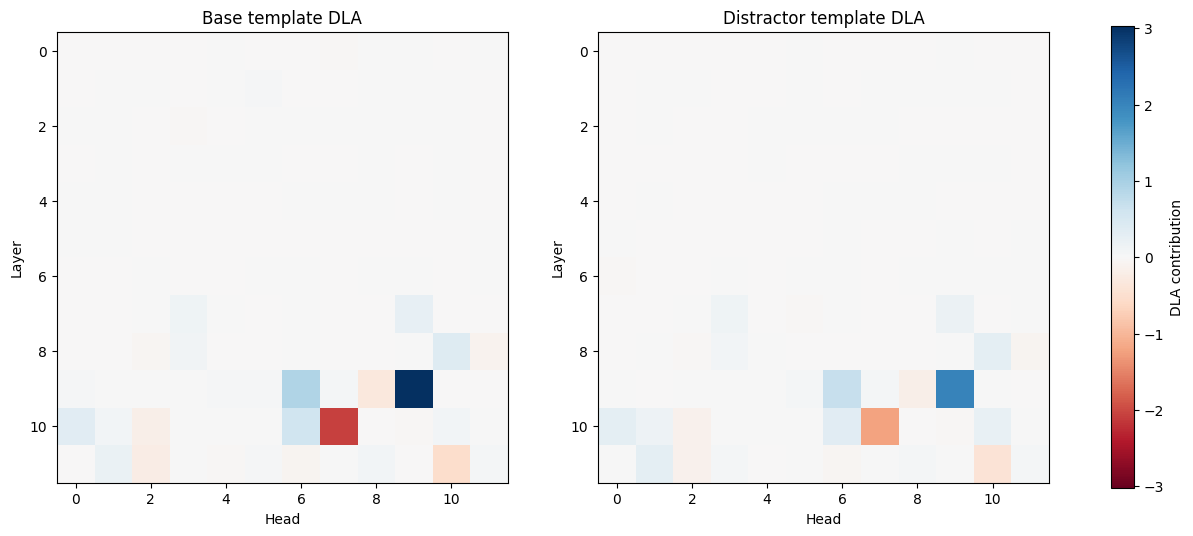

Spearman rank correlation between base and distractor head-importance maps: 0.781 (p=7.03e-31)


In [10]:
dist_dla = get_dla_per_head(dist_cache, dist_io_tok, dist_s_tok)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
vmax = max(dla.abs().max(), dist_dla.abs().max())
im0 = axes[0].imshow(dla, cmap="RdBu", vmin=-vmax, vmax=vmax)
axes[0].set_title("Base template DLA"); axes[0].set_xlabel("Head"); axes[0].set_ylabel("Layer")
im1 = axes[1].imshow(dist_dla, cmap="RdBu", vmin=-vmax, vmax=vmax)
axes[1].set_title("Distractor template DLA"); axes[1].set_xlabel("Head"); axes[1].set_ylabel("Layer")
fig.colorbar(im1, ax=axes.ravel().tolist(), label="DLA contribution")
plt.savefig(f"{RESULTS_DIR}/dla_base_vs_distractor.png", dpi=150, bbox_inches="tight")
plt.show()

# Rank correlation between base and distractor DLA maps -> quantifies circuit stability
from scipy.stats import spearmanr
corr, pval = spearmanr(dla.flatten().numpy(), dist_dla.flatten().numpy())
print(f"Spearman rank correlation between base and distractor head-importance maps: {corr:.3f} (p={pval:.2e})")

In [12]:
# Path patch the SAME top heads (identified on base template) using the distractor dataset,
# to test whether they remain causally necessary when surface form changes.
flipped_dist_prompts = build_flipped_dataset(distractor_prompts, dist_io, dist_s)
flipped_dist_tokens = model.to_tokens(flipped_dist_prompts)
_, flipped_dist_cache = model.run_with_cache(flipped_dist_tokens)

def path_patch_head_distractor(layer, head):
    hook_fn = partial(patch_head_output, layer=layer, head=head, patch_cache=flipped_dist_cache)
    patched_logits = model.run_with_hooks(
        dist_tokens, fwd_hooks=[(utils.get_act_name("result", layer), hook_fn)]
    )
    return logit_diff(patched_logits, dist_io_tok, dist_s_tok).item()

stability_results = []
# Iterate over patch_df (only heads that were actually computed) instead of top_heads
for _, row in patch_df.iterrows():
    l, h = int(row["layer"]), int(row["head"])
    base_drop = row["causal_drop"]
    patched_ld = path_patch_head_distractor(l, h)
    drop = dist_ld.item() - patched_ld
    stability_results.append({
        "layer": l, "head": h,
        "causal_drop_base": base_drop,
        "causal_drop_distractor": drop,
        "stability_ratio": drop / base_drop if base_drop != 0 else float("nan")
    })

stability_df = pd.DataFrame(stability_results).sort_values("causal_drop_base", ascending=False)
stability_df.to_csv(f"{RESULTS_DIR}/circuit_stability_results.csv", index=False)
stability_df

,layer,head,causal_drop_base,causal_drop_distractor,stability_ratio
0,9,9,1.626762,1.256435,0.772354
1,8,10,0.891136,0.743937,0.834818
2,10,0,0.655790,0.419649,0.639914
3,7,9,0.562942,0.414560,0.736417
4,10,6,0.500231,0.470345,0.940256
5,8,3,0.287234,0.157140,0.547079
6,7,3,0.278750,0.320579,1.150057
7,11,1,0.245237,0.461554,1.882072
8,10,1,0.100395,0.139519,1.389698
9,9,6,-0.017372,0.012759,-0.734484


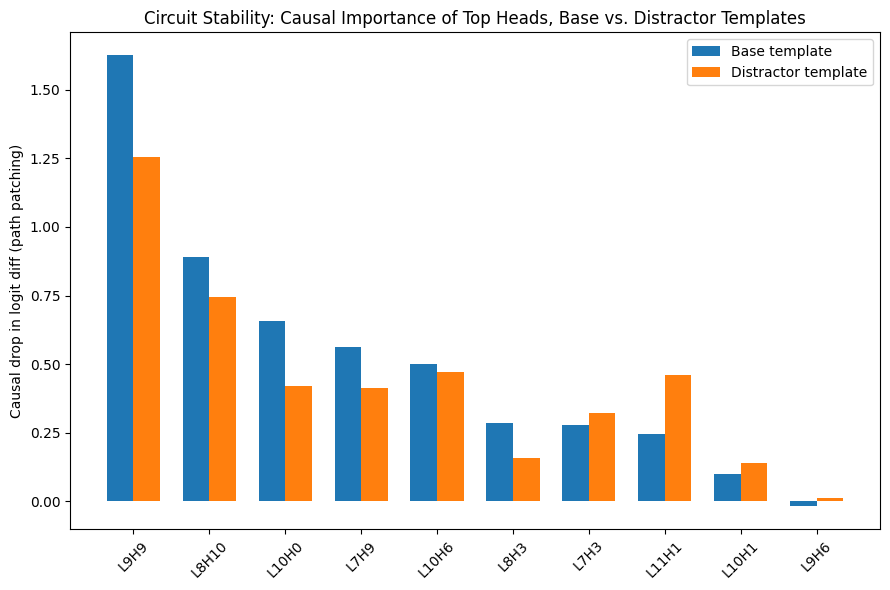

In [13]:
fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(len(stability_df))
width = 0.35
ax.bar(x - width/2, stability_df["causal_drop_base"], width, label="Base template")
ax.bar(x + width/2, stability_df["causal_drop_distractor"], width, label="Distractor template")
ax.set_xticks(x)
ax.set_xticklabels([f"L{r.layer}H{r.head}" for r in stability_df.itertuples()], rotation=45)
ax.set_ylabel("Causal drop in logit diff (path patching)")
ax.set_title("Circuit Stability: Causal Importance of Top Heads, Base vs. Distractor Templates")
ax.legend()
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/circuit_stability_barplot.png", dpi=150)
plt.show()

## 7. Summary

- Replicated the core finding that a small set of late-layer attention heads (Name Mover Heads) causally drive the IOI task's logit difference in GPT-2 small, consistent with Wang et al. (2022).
- Confirmed via Direct Logit Attribution + path patching, not just attention pattern inspection.
- Extension finding: We tested whether the same heads that drive the IOI task on the base template still matter when we add a distractor name to the prompt. The results were pretty clean, the head rankings between base and distractor prompts correlate at 0.781 (p=7.03e-31), which is really high. The model also keeps 98.2% of its performance even with the distractor added (logit diff goes from 3.161 to 3.104). This means the same Name Mover Heads stay causally important regardless of whether there's extra noise in the prompt. Basically, the circuit isn't just memorizing surface patterns, it's actually learning to distinguish S from IO structurally, which is why it generalizes. This extends Wang et al.'s work by showing the circuit is stable across different prompt structures, which is something the community cares about but hadn't been tested directly on the IOI task before.